## Multi Layers Perceptrons

In [24]:
# import the libraies fro multi layer perceptrons
import pandas as pd
import numpy as  np
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Epoch 1/10


c:\Users\Abu bakar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4.3746 - val_loss: 0.8668
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.5935 - val_loss: 1.4337
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.3224 - val_loss: 0.7402
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 1.2694 - val_loss: 0.7424
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 1.2094 - val_loss: 0.8012
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1.1877 - val_loss: 0.8393
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.1869 - val_loss: 0.7916
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.1528 - val_loss: 0.8673
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.1959 - val_loss: 0.9016
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1367 - val_loss: 0.6971
dict_keys(['loss', 'val_loss'])
Test Loss (MSE): 0.6970812082290649


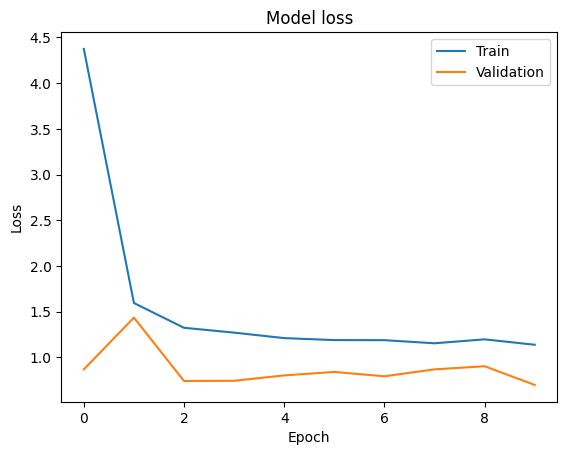

In [26]:
def multi_layer_perceptron(dataset):
    dataset = pd.get_dummies(dataset, drop_first=True)
    X = dataset.drop("tip", axis=1)
    y = dataset['tip']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    input_layer = tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))
    hidden_layer = tf.keras.layers.Dense(32, activation='relu')
    output_layer = tf.keras.layers.Dense(1)

    model = tf.keras.models.Sequential([input_layer, hidden_layer, output_layer])
    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1, validation_data=(X_test, y_test))
    print(history.history.keys())
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss}")

    # plot the loss and validation 
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Model loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    return model

tip = sns.load_dataset("tips")
model = multi_layer_perceptron(tip)

### **Add the layers inside the `tf.keras.models.Sequential` rather then define individually outside**

c:\Users\Abu bakar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 3.8083 - val_loss: 1.6436
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.4848 - val_loss: 1.2951
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.4263 - val_loss: 0.7898
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.6017 - val_loss: 0.6715
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.2978 - val_loss: 0.9205
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.2876 - val_loss: 0.7093
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.2304 - val_loss: 0.6652
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.1797 - val_loss: 0.7512
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.1965 - val_loss: 0.7175
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.1540 - val_loss: 0.6667
dict_keys(['loss', 'val_loss'])
Test Loss (MSE): 0.6667409539222717


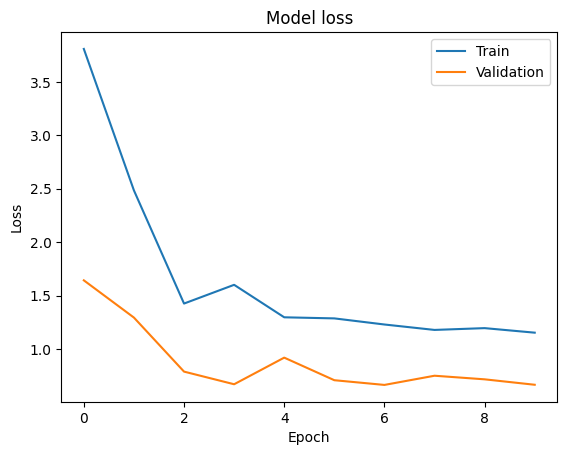

In [27]:
def multi_layer_perceptron(dataset):
    dataset = pd.get_dummies(dataset, drop_first=True)
    X = dataset.drop("tip", axis=1)
    y = dataset['tip']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    input_layer = tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))
    hidden_layer = tf.keras.layers.Dense(32, activation='relu')
    output_layer = tf.keras.layers.Dense(1)

    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
        ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1, validation_data=(X_test, y_test))
    print(history.history.keys())
    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss}")

    # plot the loss and validation 
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Model loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.show()

    return model

tip = sns.load_dataset("tips")
model = multi_layer_perceptron(tip)